In [54]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sqlalchemy import create_engine
from dotenv import load_dotenv
from warnings import filterwarnings
filterwarnings("ignore")
load_dotenv()

read_data_from_db = False

pr = lambda x: print(x, end='\n' + '-' * 50 + '\n')

In [55]:
def read_data(samples=5000):
    DATABASE_URL = os.getenv("DATABASE_URL")
    engine = create_engine(DATABASE_URL)

    data = pd.read_sql("""
        SELECT * FROM song_ml_view WHERE genre != 'unknown' AND
        song_hotttnesss IS NOT NULL AND
        artist_hotttnesss IS NOT NULL""",
        engine)
    df = data.sample(n=min(samples, len(data)), random_state=42)
    df.to_csv(f"../data/sample_{samples}.csv", index=False)

In [56]:
sample_size = 5000
if read_data_from_db:
    read_data(samples=sample_size)

data = pd.read_csv(f"../data/sample_{sample_size}.csv")
data.head()

,song_id,genre,tempo_bpm,time_signature,key_tonic,key_mode,key_confidence,song_hotttnesss,artist_hotttnesss,unique_chords,total_measures,avg_note_density,chord_entropy,pitch_range,avg_pitch,pitch_variance,avg_note_duration,note_duration_variance,melodic_interval,note_count
0,2906b3ea-a5f8-40d8-9b45-83d8ebba3673,Pop,98.00,4/4,F,major,0.965392,0.417314,0.397852,6,93,5.935484,1.714542,17,69.858696,8.455496,0.466938,0.077058,1.225045,552
1,d84c2df7-c924-4f3d-9ca6-0e194865bedb,Electronic,107.29,4/4,F,major,0.817581,0.697754,0.533117,7,103,5.038835,1.662375,19,33.797688,14.296829,0.486031,0.172222,2.142857,519
2,87530d40-4256-4343-8aa8-6229e18cd79f,Rock,121.00,4/4,F,major,0.910809,0.615280,0.305038,6,72,3.430556,1.437759,15,35.607287,13.808565,1.165992,0.291440,3.845528,247
3,67bf984d-c357-415f-9628-25e0eca2c81f,Pop,124.00,8/8,C#,major,0.896920,0.253840,0.364456,6,106,0.641509,1.673444,12,34.147059,14.664618,1.944853,1.775831,1.925373,68
4,84e97cae-46a0-4770-9911-9f1dd2200162,Rock,88.00,4/4,F,major,0.657337,0.777617,0.683658,4,68,3.352941,1.152361,14,72.504386,7.044034,0.485380,0.213931,2.202643,228


In [57]:
df = data.copy()
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   song_id                 5000 non-null   object 
 1   genre                   5000 non-null   object 
 2   tempo_bpm               5000 non-null   float64
 3   time_signature          5000 non-null   object 
 4   key_tonic               5000 non-null   object 
 5   key_mode                5000 non-null   object 
 6   key_confidence          5000 non-null   float64
 7   song_hotttnesss         5000 non-null   float64
 8   artist_hotttnesss       5000 non-null   float64
 9   unique_chords           5000 non-null   int64  
 10  total_measures          5000 non-null   int64  
 11  avg_note_density        5000 non-null   float64
 12  chord_entropy           5000 non-null   float64
 13  pitch_range             5000 non-null   int64  
 14  avg_pitch               5000 non-null   

(None, (5000, 20))

In [58]:
df.isna().sum()

song_id                   0
genre                     0
tempo_bpm                 0
time_signature            0
key_tonic                 0
key_mode                  0
key_confidence            0
song_hotttnesss           0
artist_hotttnesss         0
unique_chords             0
total_measures            0
avg_note_density          0
chord_entropy             0
pitch_range               0
avg_pitch                 0
pitch_variance            0
avg_note_duration         0
note_duration_variance    0
melodic_interval          0
note_count                0
dtype: int64

In [59]:
df.nunique()

song_id                   5000
genre                       15
tempo_bpm                  367
time_signature              21
key_tonic                   13
key_mode                     2
key_confidence            4376
song_hotttnesss           1892
artist_hotttnesss         1671
unique_chords               13
total_measures             253
avg_note_density          3124
chord_entropy             3030
pitch_range                 86
avg_pitch                 3340
pitch_variance            3497
avg_note_duration         3288
note_duration_variance    3480
melodic_interval          3165
note_count                 652
dtype: int64

In [60]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tempo_bpm,5000.0,110.483386,33.229487,30.000000,85.000000,110.000000,127.000000,500.000000
key_confidence,5000.0,0.841140,0.080053,0.000000,0.805214,0.855594,0.894839,0.988014
song_hotttnesss,5000.0,0.614004,0.174091,0.192394,0.490808,0.619525,0.742420,1.000000
artist_hotttnesss,5000.0,0.500942,0.110473,0.144685,0.418562,0.492074,0.562158,1.021256
unique_chords,5000.0,4.975400,2.804776,0.000000,3.000000,5.000000,7.000000,12.000000
total_measures,5000.0,102.063600,41.357133,1.000000,76.000000,98.000000,124.000000,318.000000
avg_note_density,5000.0,1.563994,1.905377,0.000000,0.233656,0.686471,2.567778,16.000000
chord_entropy,5000.0,1.201864,0.636394,0.000000,0.858696,1.386294,1.675128,2.396838
pitch_range,5000.0,24.446000,18.105343,0.000000,12.000000,21.000000,36.000000,100.000000
avg_pitch,5000.0,52.867568,22.099295,0.000000,42.142857,60.726753,67.000000,127.000000


In [61]:
# Check skewed features
df[num_cols].skew().sort_values(ascending=False)

note_duration_variance    36.251001
avg_note_duration          8.464374
pitch_variance             5.597148
note_count                 2.531728
melodic_interval           2.215823
avg_note_density           1.960475
tempo_bpm                  1.221368
artist_hotttnesss          0.887136
total_measures             0.855512
pitch_range                0.629136
song_hotttnesss           -0.119626
unique_chords             -0.195296
chord_entropy             -0.789444
avg_pitch                 -1.286963
key_confidence            -2.059329
dtype: float64

In [62]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df[cat_cols].describe().T

,count,unique,top,freq
song_id,5000,5000,2906b3ea-a5f8-40d8-9b45-83d8ebba3673,1
genre,5000,15,Rock,1910
time_signature,5000,21,4/4,4570
key_tonic,5000,13,C,781
key_mode,5000,2,major,3382


## Observations
- Some columns have all unique values (song_id)
- `key_mode` has only 2 unique values
- Some of the outliers are obviously errors in encoding, for example:
  - `note_count`, `avg_pitch`, `pitch_range` = 0
- Some are also too extreme to be useful, for example:
  - `tempo_bpm` > 300
  - `pitch_variance` > 1000
  - `avg_note_density` > 20
  - `note_count` > 1000
- Right-skewed features (note_count, pitch_variance, note_duration_variance) can be log-transformed
- Additonal complexity score would be helpful in further analysis

## Data cleaning and preprocessing
- Drop columns where have either all unique values or are the same throughout
- Encode key_mode as there are only 2 variations
- Scale skewed columns logarithmically
- Filter out songs with extreme tempos, zero notes, or zero average pitch or range, which are likely data errors or outliers
- Compute complexity score


In [63]:
df_transformed = df.copy()

In [64]:
# Drop columns with all unique values (e.g., song_id, artist_id) or only one unique value (e.g., key_mode if all songs are in the same mode)
df_transformed.drop(columns=[col for col in df_transformed.columns if df_transformed[col].nunique() == len(df_transformed)], inplace=True)
df_transformed.drop(columns=[col for col in df_transformed.columns if df_transformed[col].nunique() == 1], inplace=True)

In [65]:
# Encode key_mode as binary feature (1 for major, 0 for minor)
df_transformed['is_major'] = (df_transformed['key_mode'] == 'major').astype(int)

In [66]:
# Transform skewed features with log transformation
skewed_cols = df[num_cols].skew().abs() > 1 # Threshold for skewness (rule of thumb: >1 is highly skewed)
skewed_cols[skewed_cols].index.tolist()

['tempo_bpm',
 'key_confidence',
 'avg_note_density',
 'avg_pitch',
 'pitch_variance',
 'avg_note_duration',
 'note_duration_variance',
 'melodic_interval',
 'note_count']

In [67]:
# Based on skewness analysis, we will apply log transformation to the following features:
log_cols = [
    'pitch_variance', 'note_duration_variance',
    'melodic_interval', 'total_measures',
    'avg_note_duration'
]

df_transformed[log_cols] = np.log1p(df_transformed[log_cols])

# for col in log_cols:
#     print(f"Applying log transformation to {col} (skewness: {df_transformed[col].skew():.2f})")
#     df_transformed[f"{col}_log"] = np.log1p(df_transformed[col])
#     df_transformed.drop(columns=col, inplace=True)

In [68]:
# Filter out outliers based on domain knowledge and feature distributions
df_transformed = df_transformed[
    (df_transformed["tempo_bpm"] <= 300) &
    (df_transformed["note_count"] > 0) &
    (df_transformed["avg_pitch"] > 0) &
    (df_transformed["pitch_range"] > 0) &
    (df_transformed["pitch_variance"] < 1000) &
    (df_transformed["avg_note_density"] < 20) & 
    (df_transformed["note_count"] < 800) &
    (df_transformed["key_confidence"] > 0.0)
]

In [69]:
# Create a composite complexity score by combining multiple features that contribute to musical complexity. We will use a simple equal-weighted average of the following features:
complexity_cols = [
    'key_confidence',        # inverted — lower = more complex
    'unique_chords',
    'chord_entropy',
    'pitch_range',
    'pitch_variance',
    'melodic_interval',
    'avg_note_density',
    'note_duration_variance',
]

# Log-transform skewed features before scaling
log_first = ['pitch_variance', 'melodic_interval', 'avg_note_density',
             'note_duration_variance', 'pitch_range']

sub = df[complexity_cols].copy()
sub[log_first] = np.log1p(sub[log_first])

# RobustScaler — median/IQR based, not thrown off by outliers
scaled = pd.DataFrame(
    RobustScaler().fit_transform(sub),
    columns=complexity_cols,
    index=df.index
)

# Invert key_confidence so direction is consistent (high = complex)
scaled['key_confidence'] = -scaled['key_confidence']

# Equal-weight mean across all components
df_transformed['complexity_score'] = scaled.mean(axis=1)

df_transformed.head()

,genre,tempo_bpm,time_signature,key_tonic,key_mode,key_confidence,song_hotttnesss,artist_hotttnesss,unique_chords,total_measures,...,chord_entropy,pitch_range,avg_pitch,pitch_variance,avg_note_duration,note_duration_variance,melodic_interval,note_count,is_major,complexity_score
0,Pop,98.00,4/4,F,major,0.965392,0.417314,0.397852,6,4.543295,...,1.714542,17,69.858696,2.246596,0.383178,0.074234,0.799777,552,1,-0.110460
1,Electronic,107.29,4/4,F,major,0.817581,0.697754,0.533117,7,4.644391,...,1.662375,19,33.797688,2.727646,0.396109,0.158901,1.145132,519,1,0.192808
2,Rock,121.00,4/4,F,major,0.910809,0.615280,0.305038,6,4.290459,...,1.437759,15,35.607287,2.695206,0.772878,0.255758,1.578056,247,1,-0.008829
3,Pop,124.00,8/8,C#,major,0.896920,0.253840,0.364456,6,4.672829,...,1.673444,12,34.147059,2.751405,1.080059,1.020950,1.073422,68,1,-0.052348
4,Rock,88.00,4/4,F,major,0.657337,0.777617,0.683658,4,4.234107,...,1.152361,14,72.504386,2.084931,0.395671,0.193864,1.163976,228,1,0.138547


In [70]:
num_cols = df_transformed.select_dtypes(include=np.number).columns
cat_cols = df_transformed.select_dtypes(include=[object]).columns

In [71]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4227 entries, 0 to 4998
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genre                   4227 non-null   object 
 1   tempo_bpm               4227 non-null   float64
 2   time_signature          4227 non-null   object 
 3   key_tonic               4227 non-null   object 
 4   key_mode                4227 non-null   object 
 5   key_confidence          4227 non-null   float64
 6   song_hotttnesss         4227 non-null   float64
 7   artist_hotttnesss       4227 non-null   float64
 8   unique_chords           4227 non-null   int64  
 9   total_measures          4227 non-null   float64
 10  avg_note_density        4227 non-null   float64
 11  chord_entropy           4227 non-null   float64
 12  pitch_range             4227 non-null   int64  
 13  avg_pitch               4227 non-null   float64
 14  pitch_variance          4227 non-null   float

In [72]:
df_transformed.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
tempo_bpm,4227.0,110.129271,32.721661,30.000000,85.000000,110.000000,126.000000,300.000000
key_confidence,4227.0,0.845365,0.074569,0.358594,0.810121,0.857952,0.897185,0.988014
song_hotttnesss,4227.0,0.612883,0.172805,0.198685,0.490904,0.618391,0.741191,1.000000
artist_hotttnesss,4227.0,0.499359,0.108452,0.144685,0.417470,0.490348,0.562677,1.021256
unique_chords,4227.0,5.715874,2.217352,1.000000,4.000000,6.000000,7.000000,12.000000
total_measures,4227.0,4.558629,0.441430,1.386294,4.356709,4.605170,4.828314,5.765191
avg_note_density,4227.0,1.682873,1.744430,0.011765,0.381088,0.904762,2.721871,16.000000
chord_entropy,4227.0,1.392020,0.451760,0.000000,1.158496,1.480864,1.704457,2.396838
pitch_range,4227.0,28.438136,16.529417,1.000000,16.000000,24.000000,41.000000,100.000000
avg_pitch,4227.0,59.567655,12.630126,25.674267,53.514535,62.285714,67.942498,100.768595


# Univariate categorical variables

In [73]:
df_transformed[cat_cols].describe(include=[object]).T

,count,unique,top,freq
genre,4227,15,Rock,1598
time_signature,4227,19,4/4,3855
key_tonic,4227,13,C,644
key_mode,4227,2,major,2907


In [81]:
for col in cat_cols:
    pr(df_transformed[col].value_counts())

genre
Rock          1598
Pop           1365
Country        327
Electronic     202
RnB            145
Latin          136
Jazz           107
New Age         78
Metal           73
World           57
Blues           45
Rap             39
Folk            32
Punk            15
Reggae           8
Name: count, dtype: int64
--------------------------------------------------
time_signature
4/4     3855
3/4      124
2/4       71
6/8       46
12/8      34
6/4       23
1/4       19
8/8       18
5/4       10
2/2        8
1/8        4
8/4        4
2/16       3
1/16       2
3/8        2
7/4        1
4/16       1
10/8       1
9/8        1
Name: count, dtype: int64
--------------------------------------------------
key_tonic
C     644
A     554
D     535
G     495
F     448
E     402
B-    263
E-    235
B     210
F#    153
C#    150
A-    114
G#     24
Name: count, dtype: int64
--------------------------------------------------
key_mode
major    2907
minor    1320
Name: count, dtype: int64
-------------

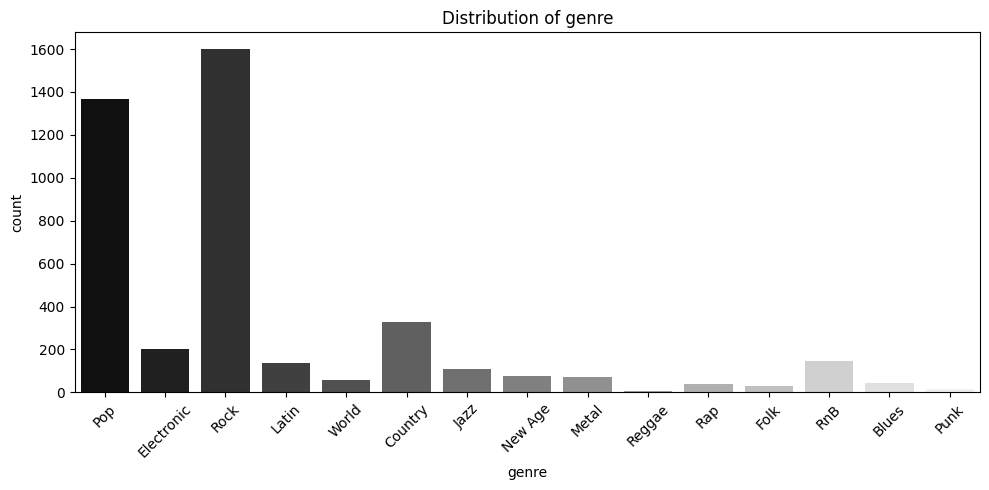

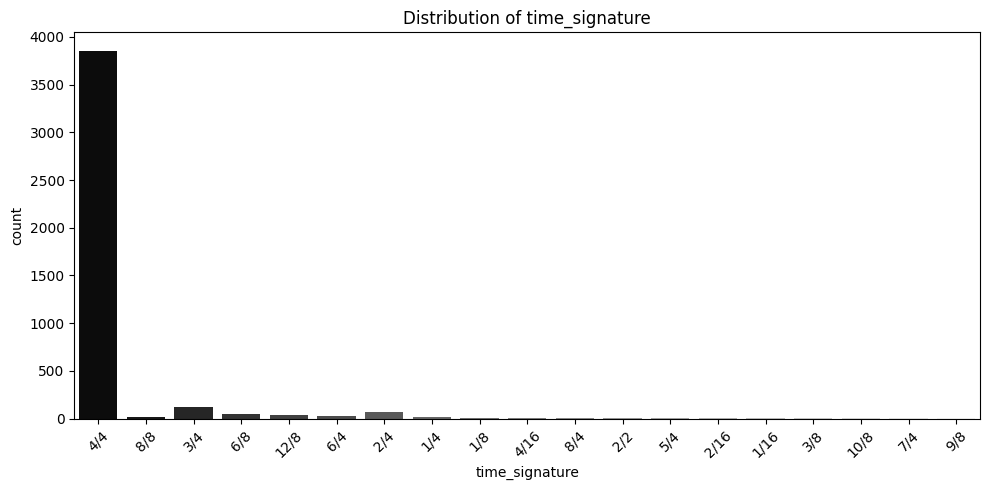

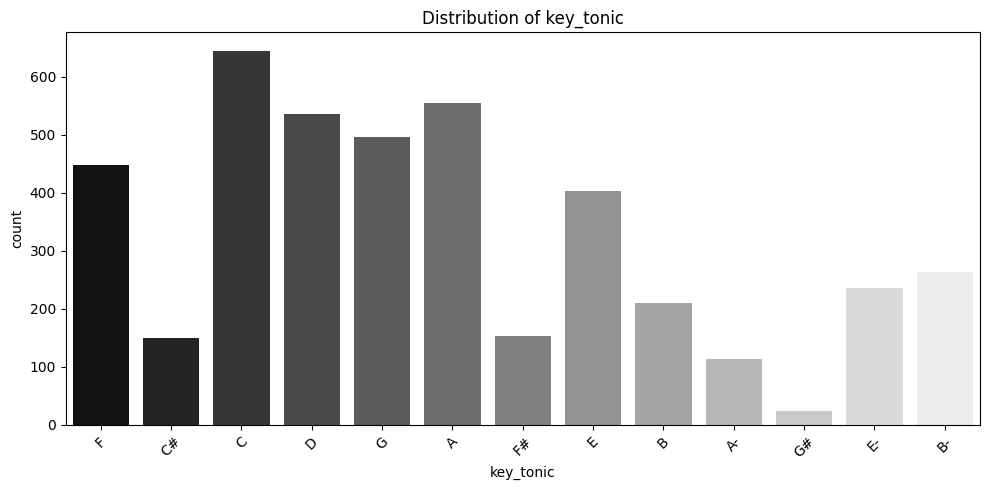

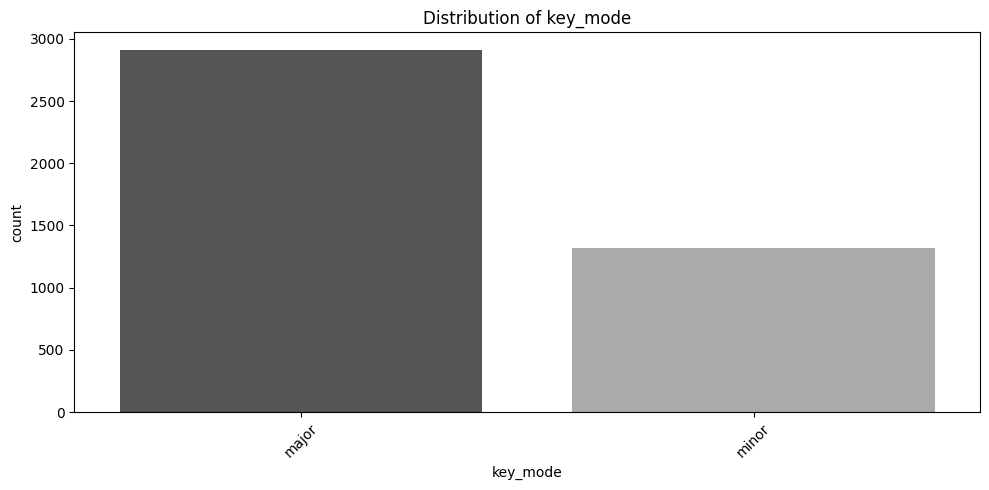

In [75]:
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_transformed, x=col, saturation=0.8, palette="gray")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Observations

# Univariate continuous variables

In [76]:
# Function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):

    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    _, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,  # Number of rows of the subplot grid= 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "green"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()  # Show the plot

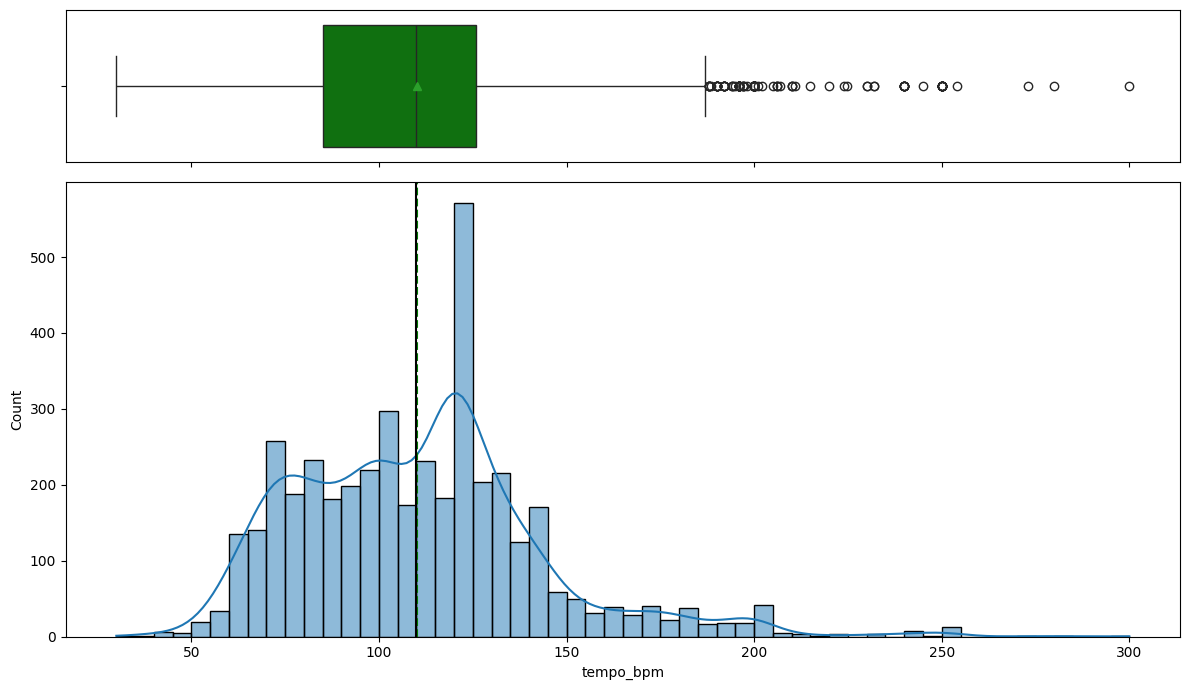

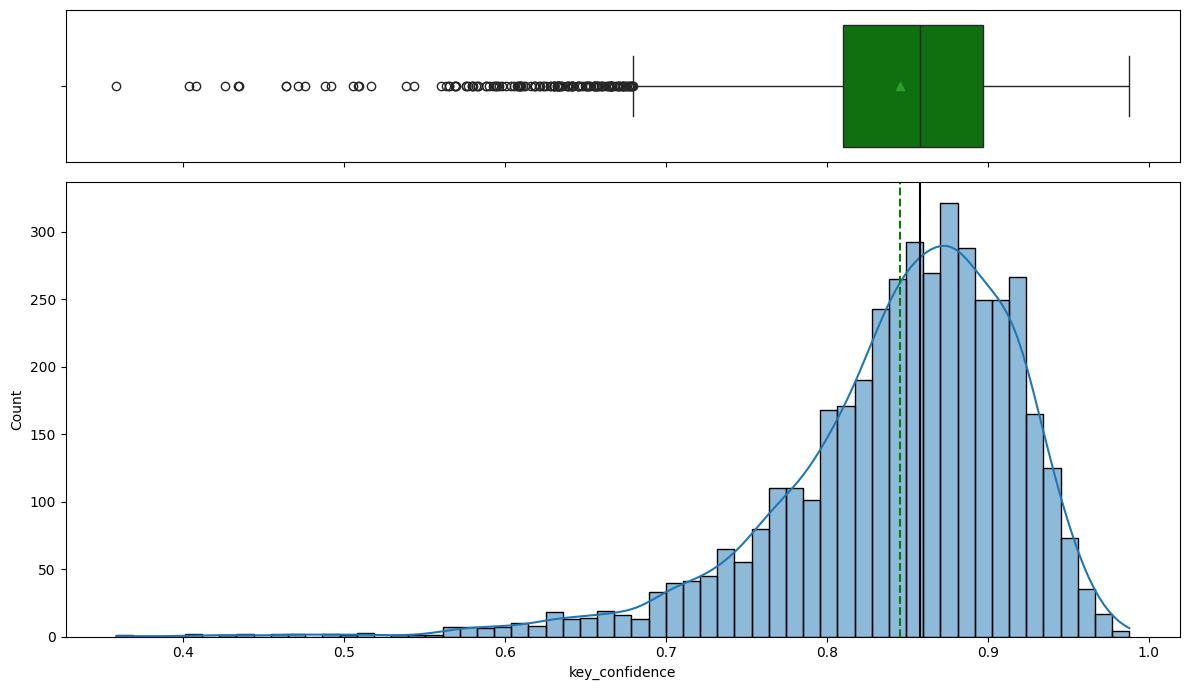

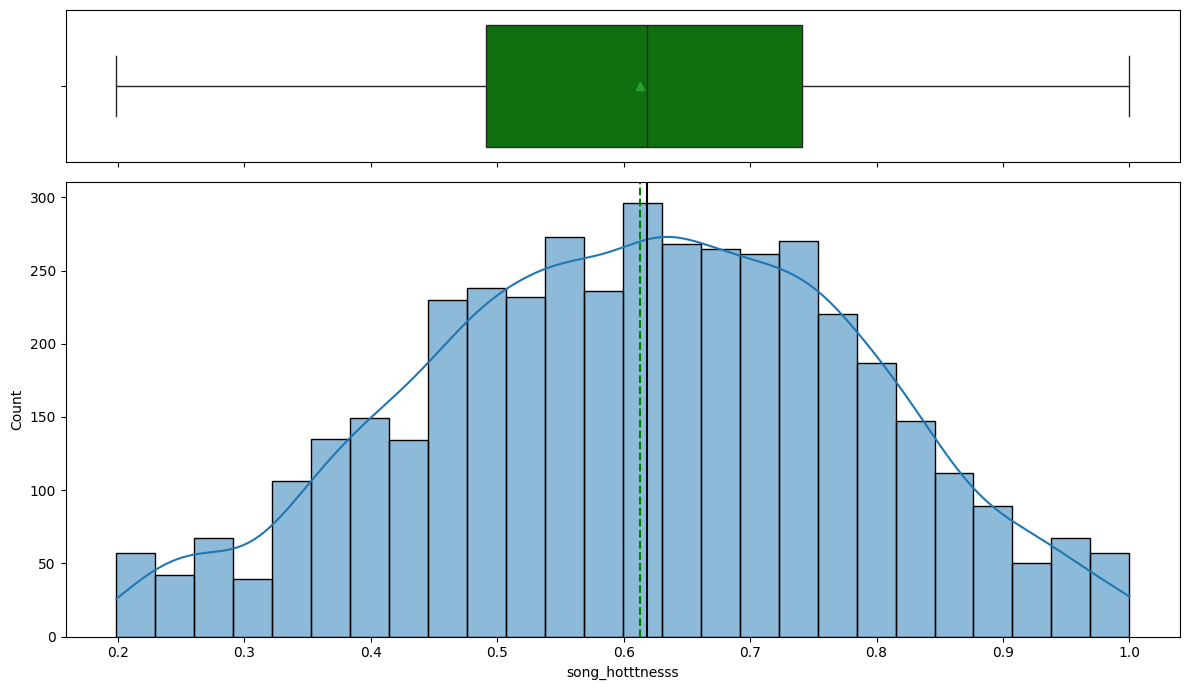

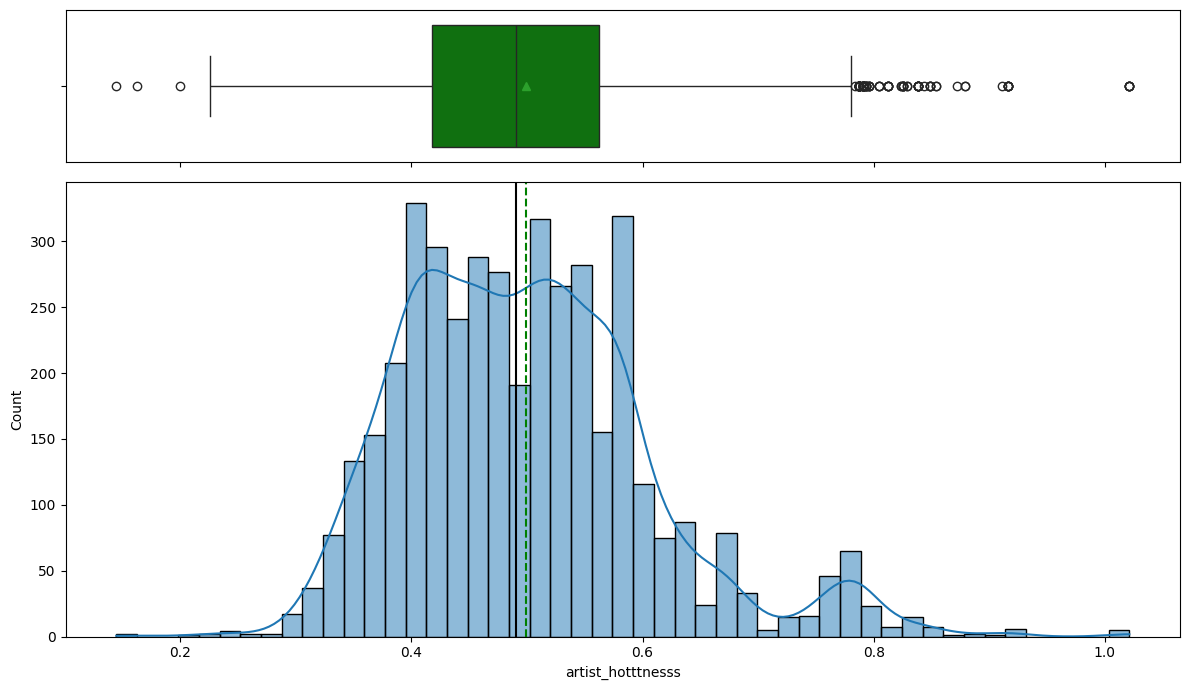

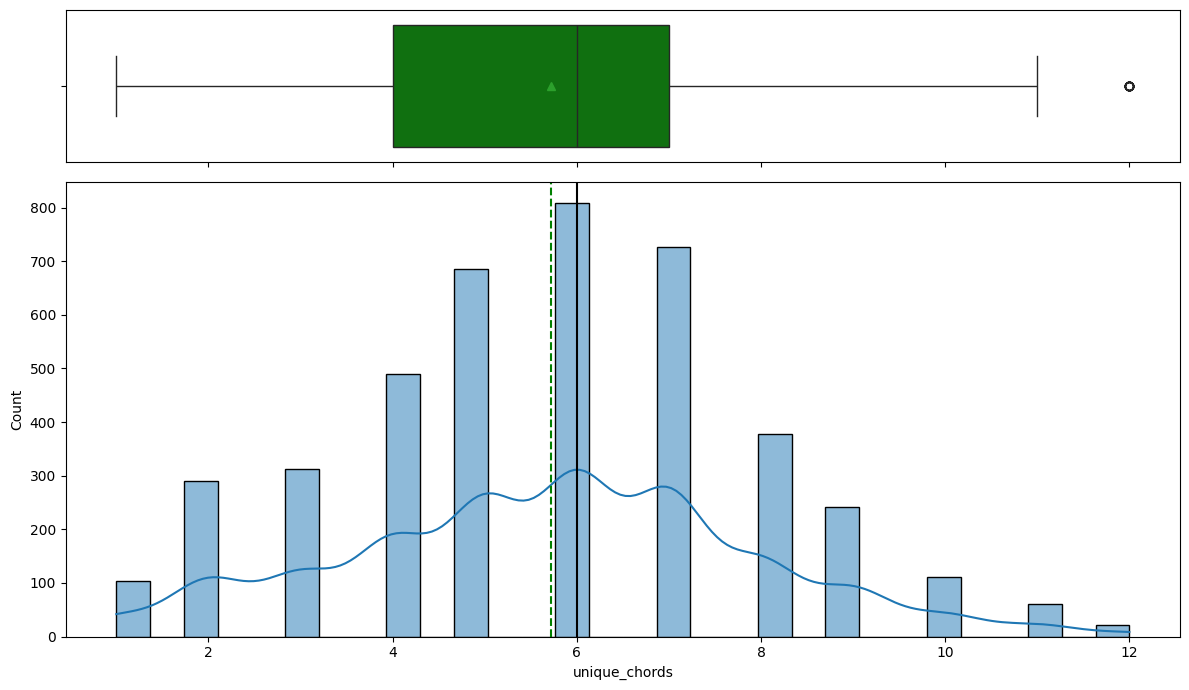

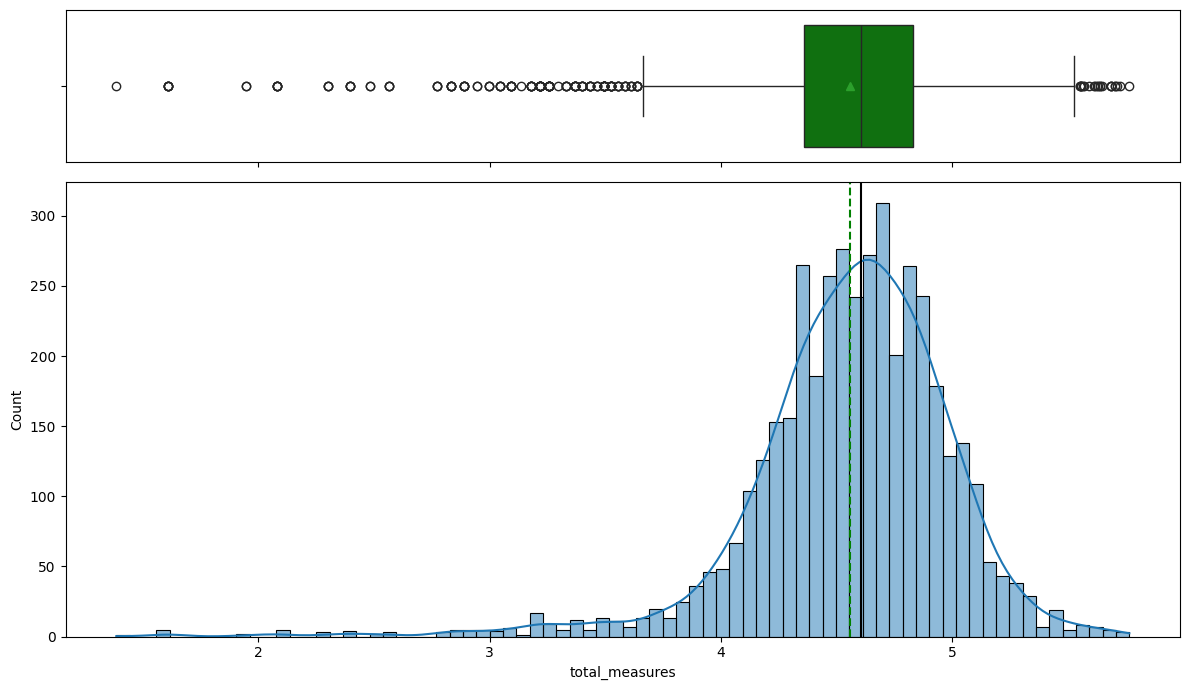

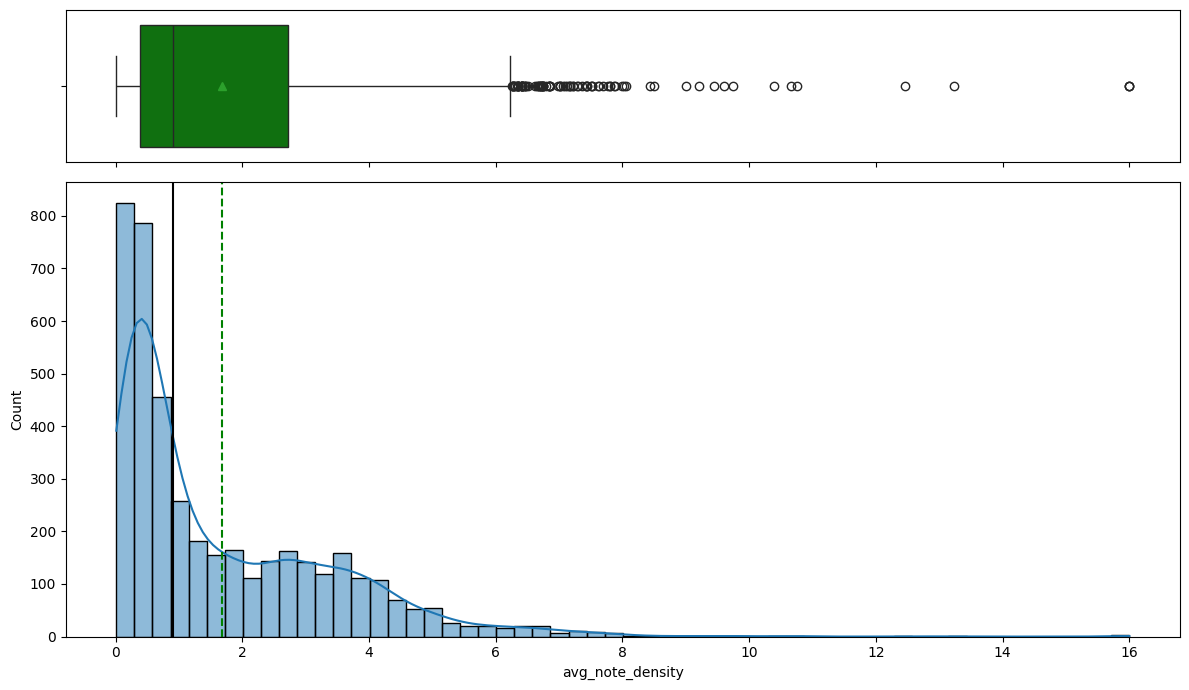

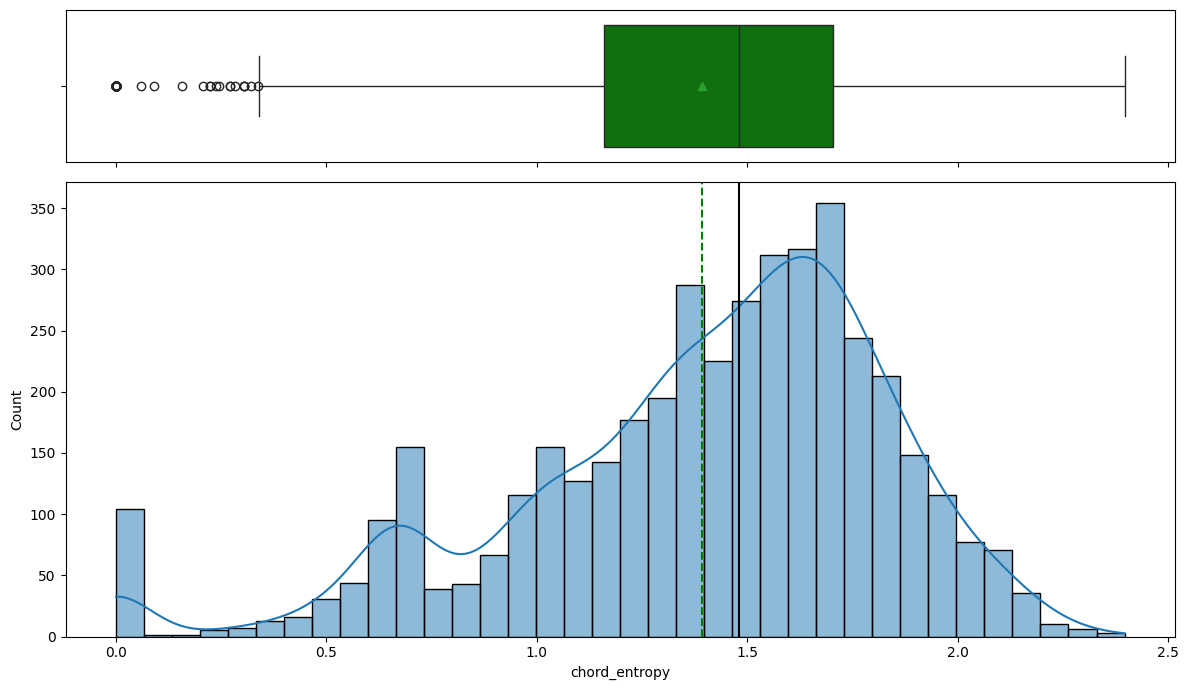

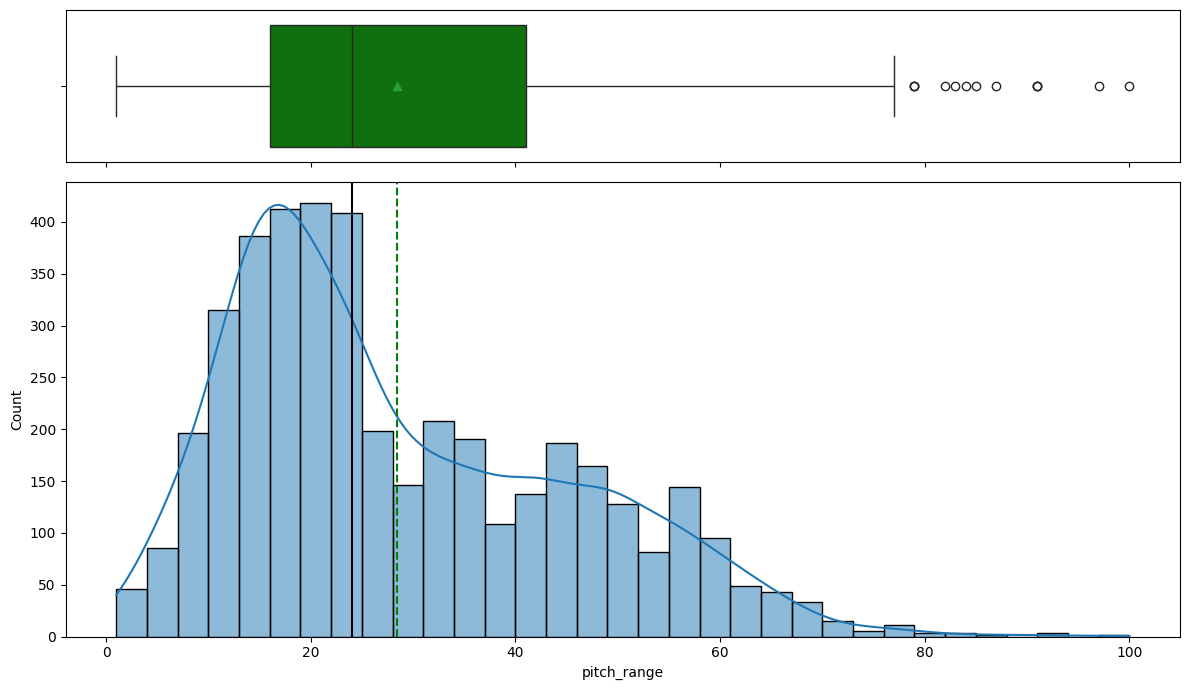

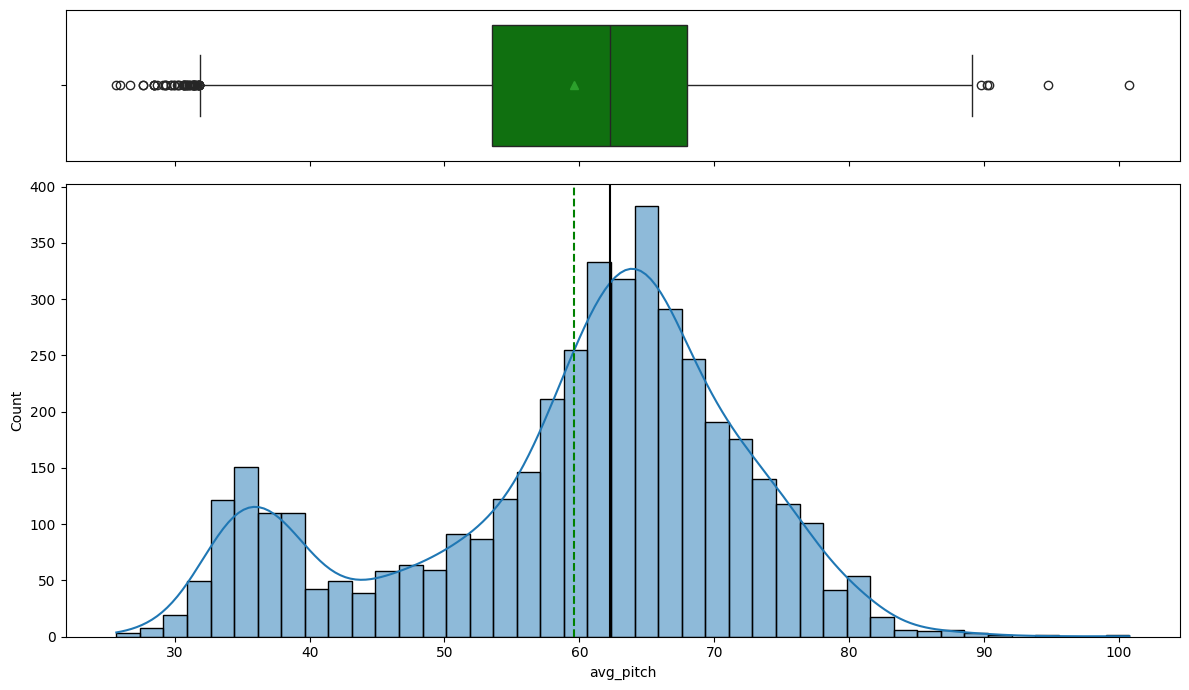

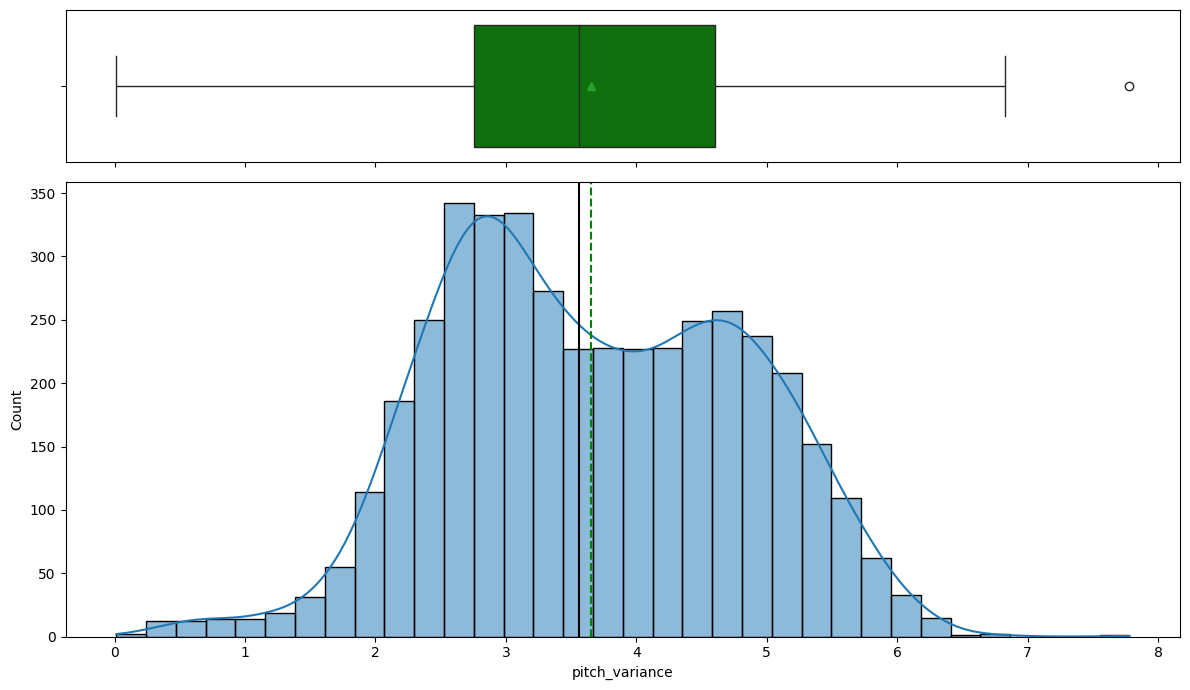

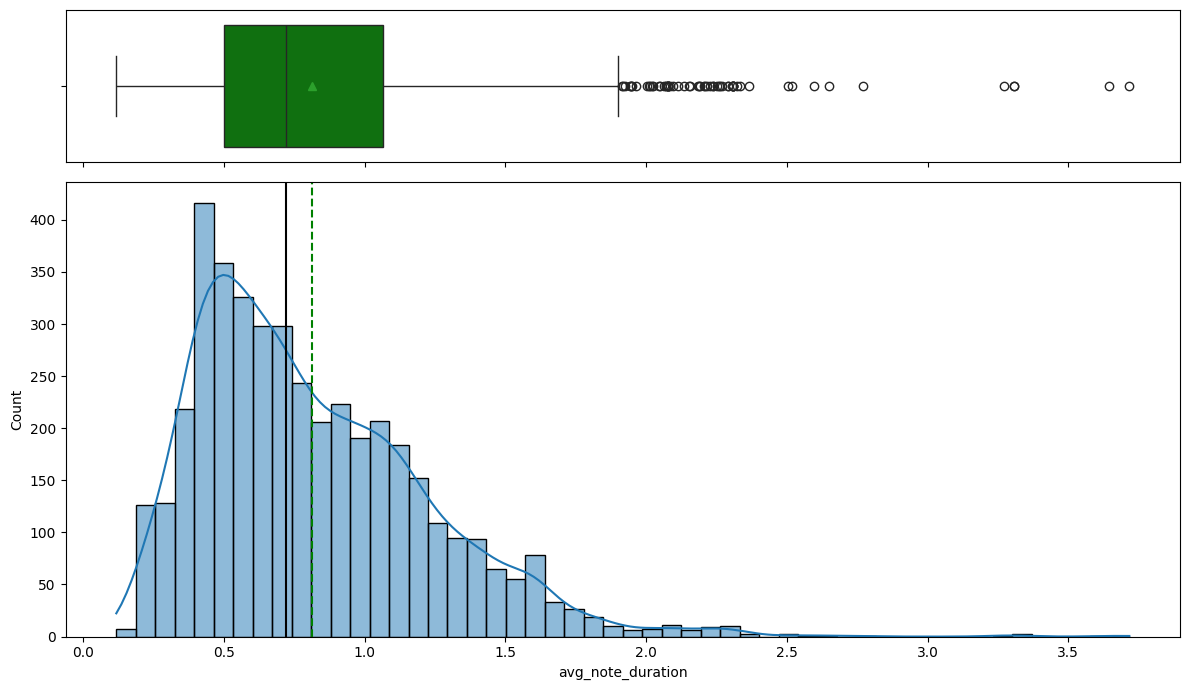

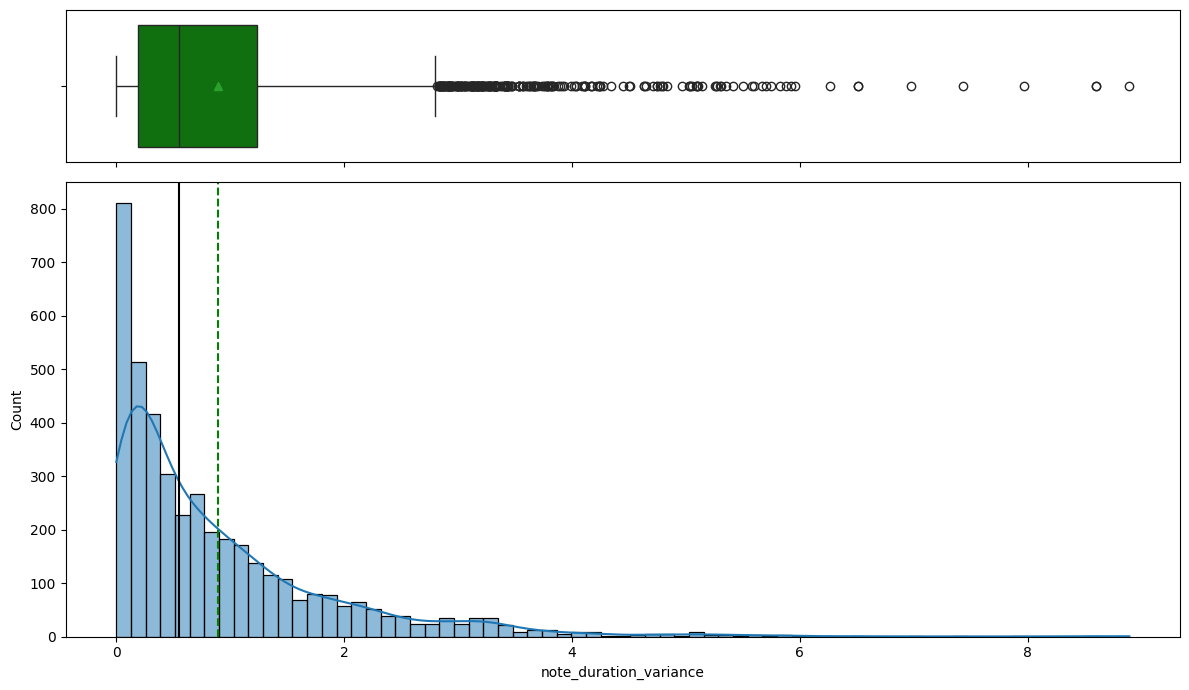

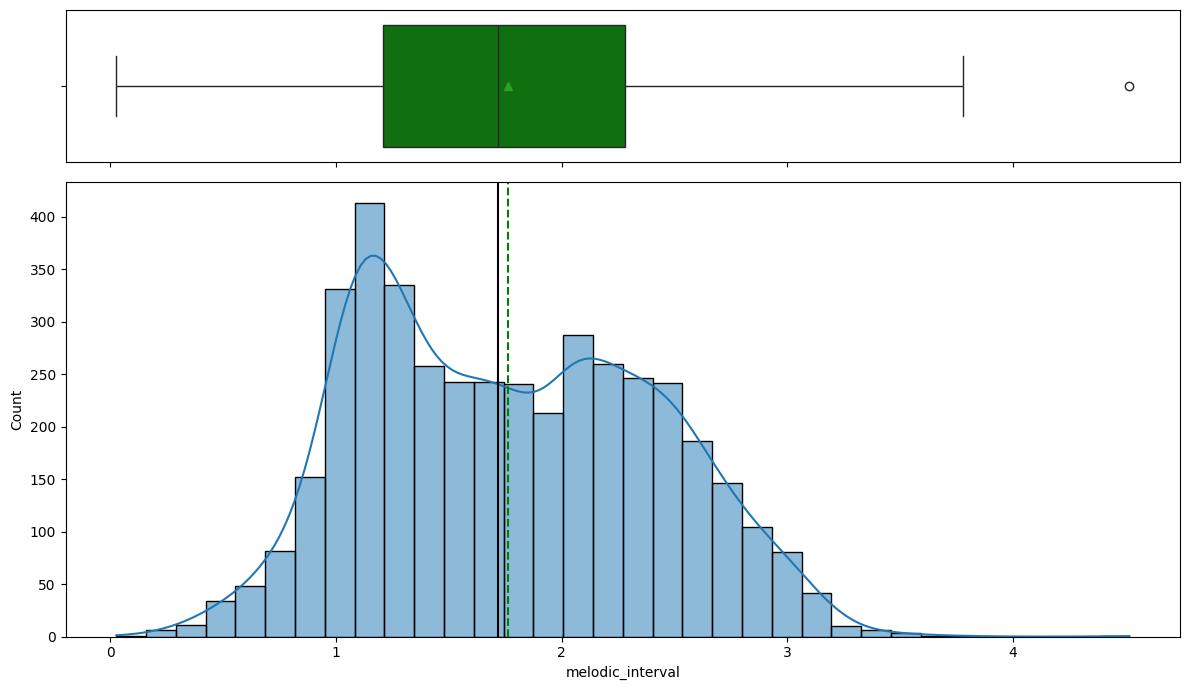

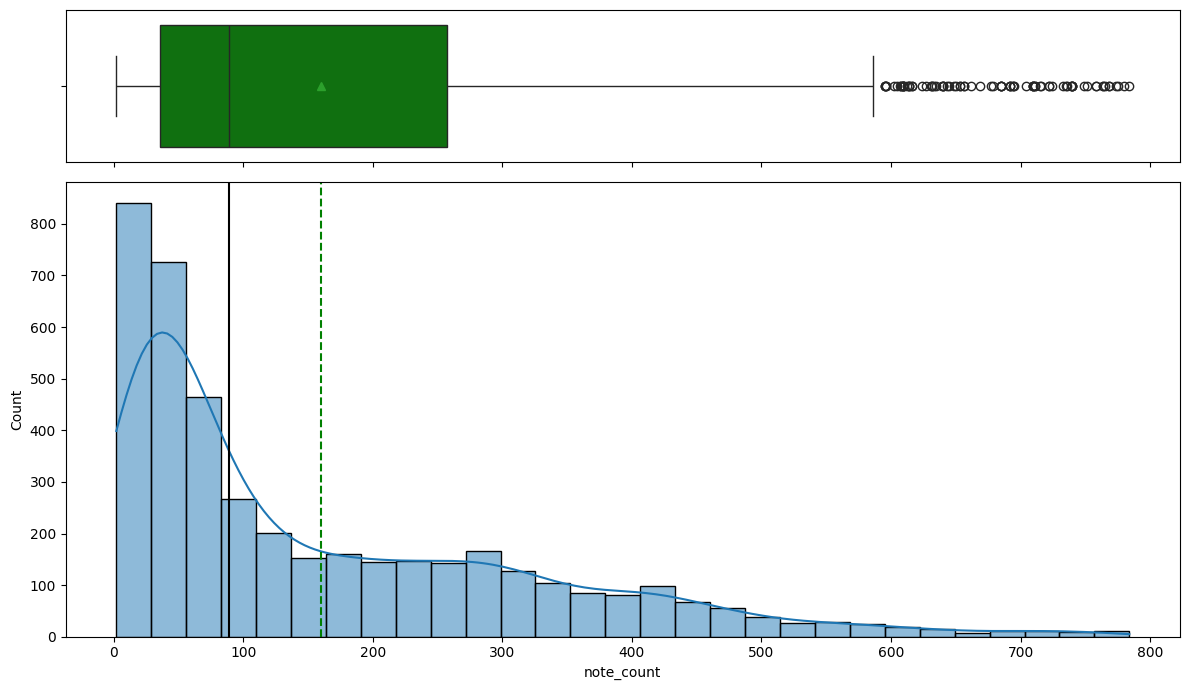

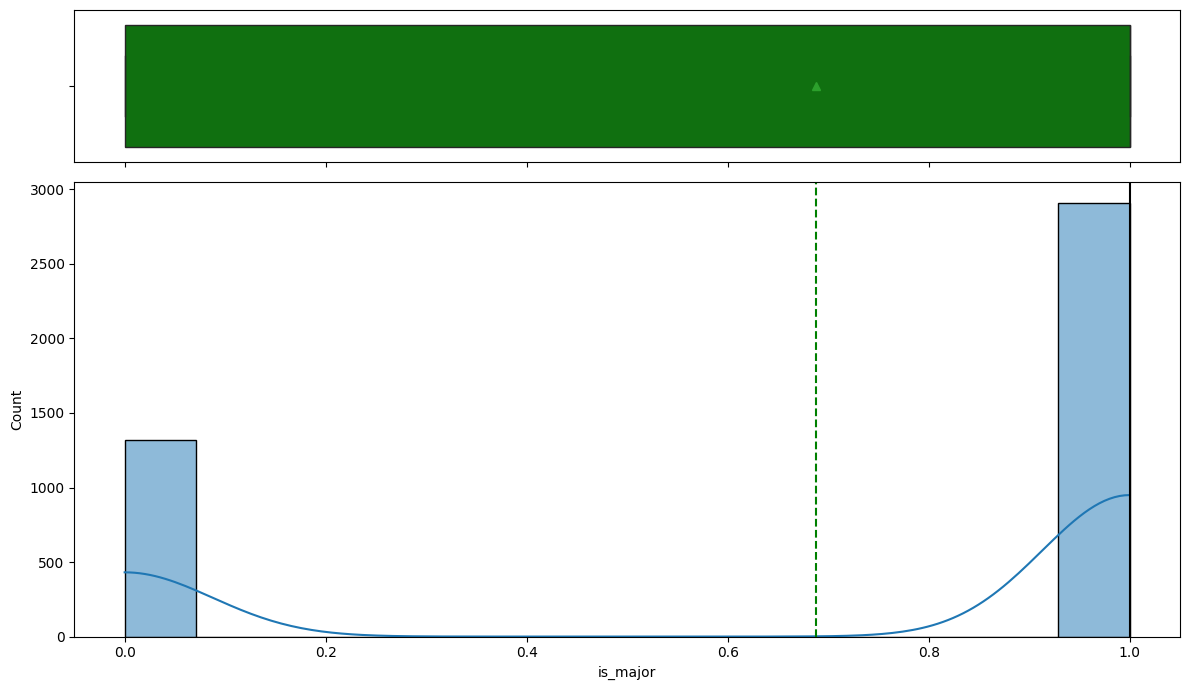

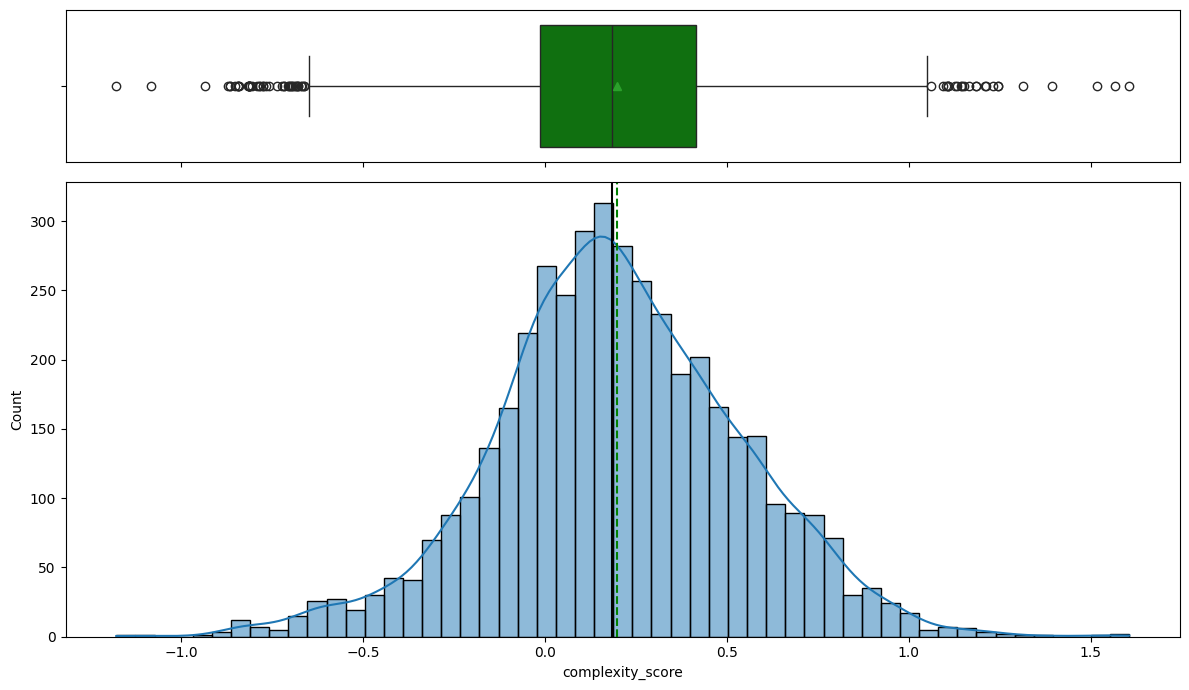

In [77]:
for col in num_cols:
    histogram_boxplot(df_transformed, col, kde=True)

# Observations
- tempo_bpm
- key_confidence
- unique_chords
- chord_entropy
- pitch_range
- avg_pitch

- note_count_log
- pitch_variance_log
- note_duration_variance_log
- melodic_interval_log
- avg_note_density_log
- total_measures_log
- avg_note_duration_log


# Multivariate analysis

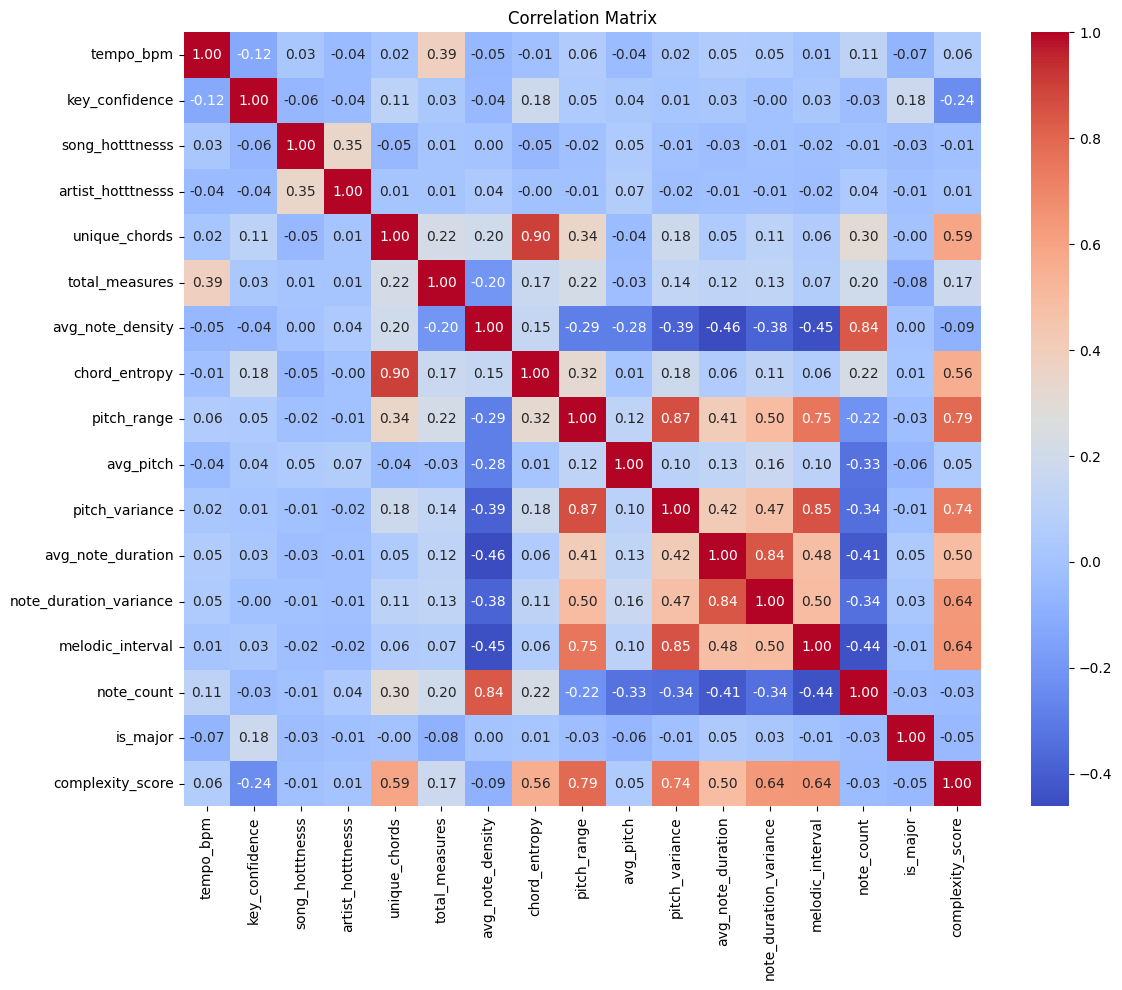

In [82]:
corr = df_transformed.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmax=1)
plt.title("Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

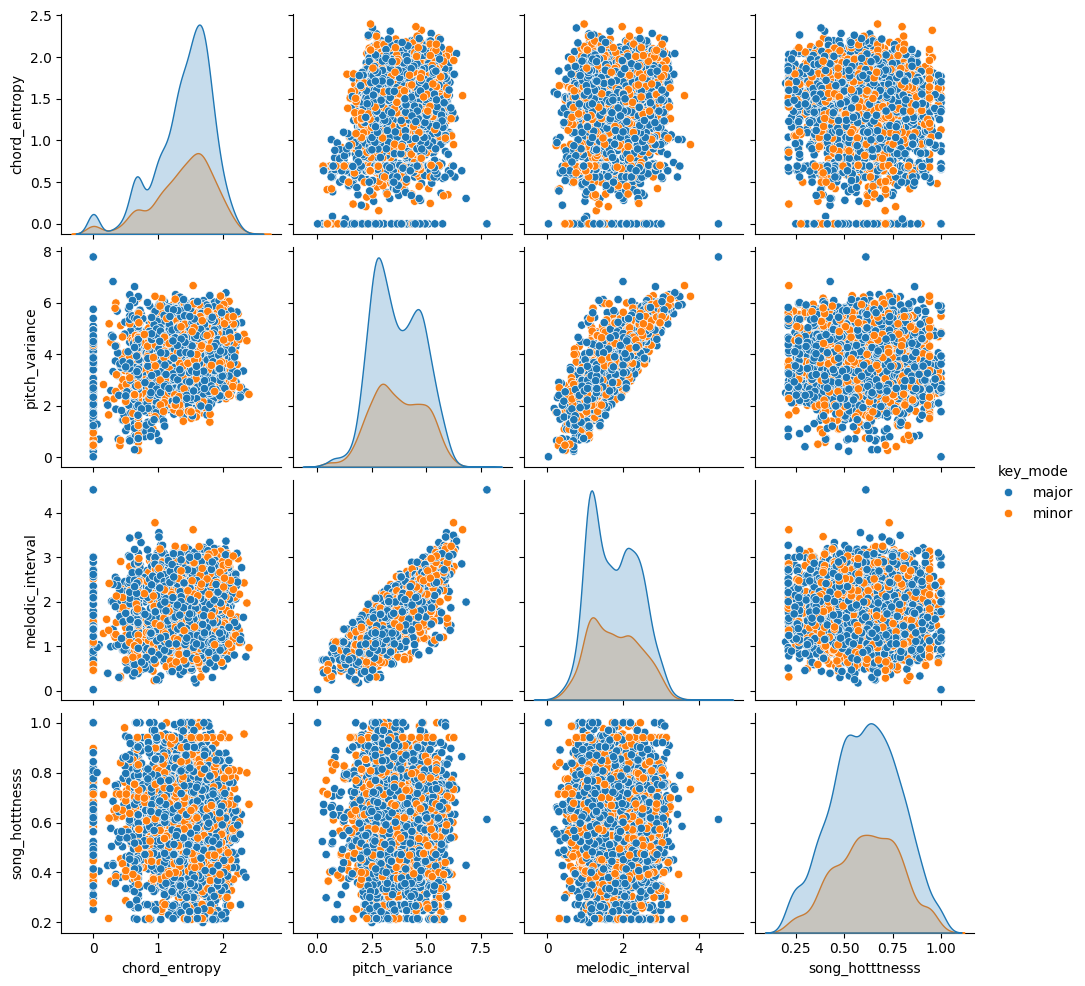

In [83]:
sns.pairplot(df_transformed[['chord_entropy', 'pitch_variance', 'melodic_interval', 
                              'song_hotttnesss', 'key_mode']], hue='key_mode')

# Observations
### Positive correlations
- High correlation between chord_entropy and unique_chords: makes sense as higher chord_entropy indicates more variation from the tonal center.
- High correlation between pitch_variance and pitch_range: higher pitch range should correlate with variance. If a range is consistently over multiple octaves, the variance would also increase.
- High correlation between pitch_range and pitch_variance and melodic_interval: this also aligns with the previous observation, in that pieces which span multiple octaves would also tend to have higher intervals between frets, whereas a piece with a low pitch_range would tend to have smaller jumps.
- High correlation between avg_note_duration and note_duration_variance, which is interesting as this indicates pieces with longer counts are indicative of higher rhythmic complexity.
- Medium correlation between 


### Negative correlations

# Further analysis
- 

In [84]:
def scatter_with_trendline(data, x, y):
    plt.figure(figsize=(10, 6))
    sns.regplot(data=data, x=x, y=y, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"{y} vs {x} with Trendline")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

def line_with_trendline(data, x, y):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x, y=y)
    plt.title(f"{y} vs {x} with Line")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

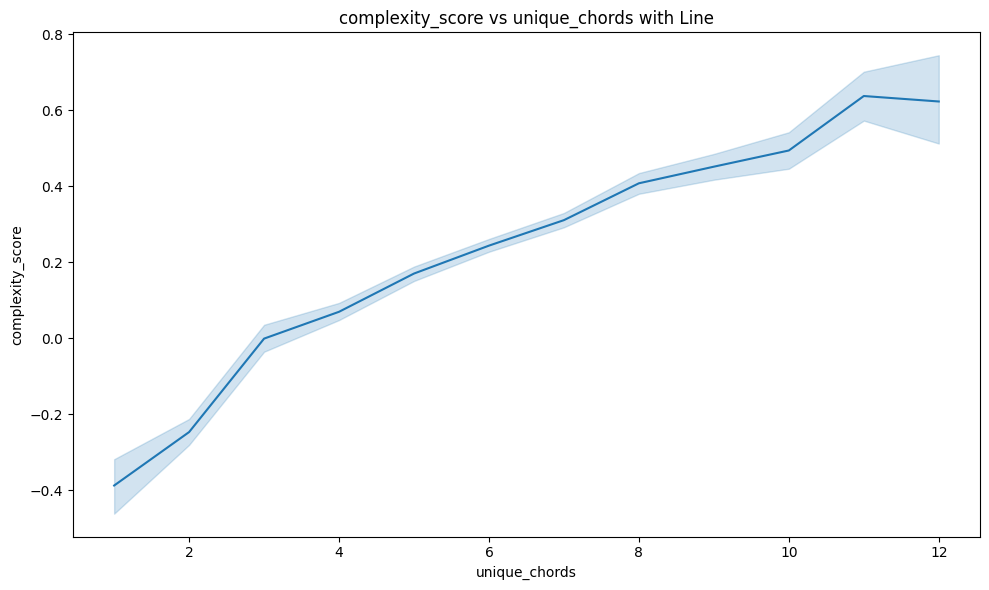

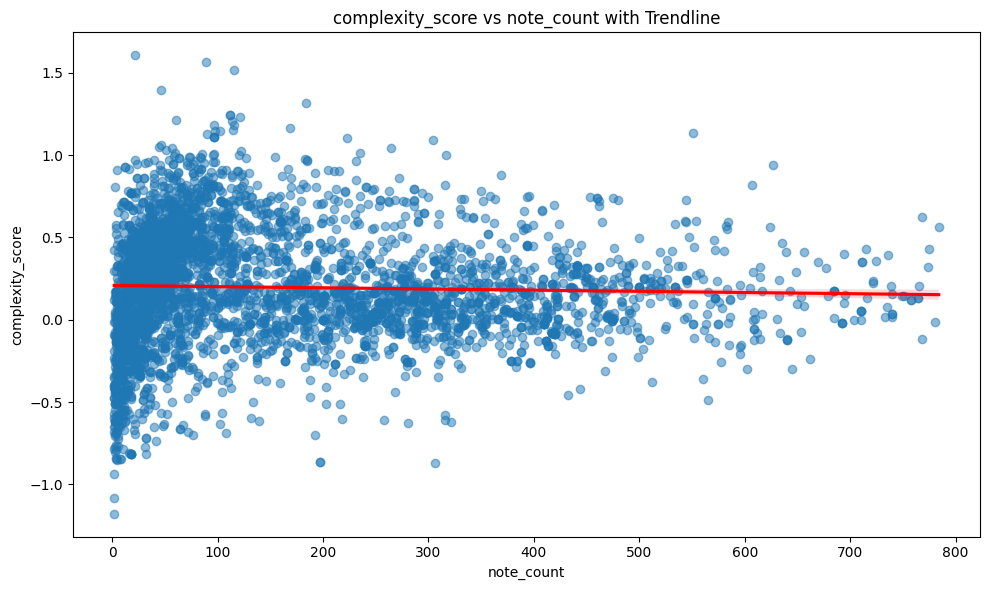

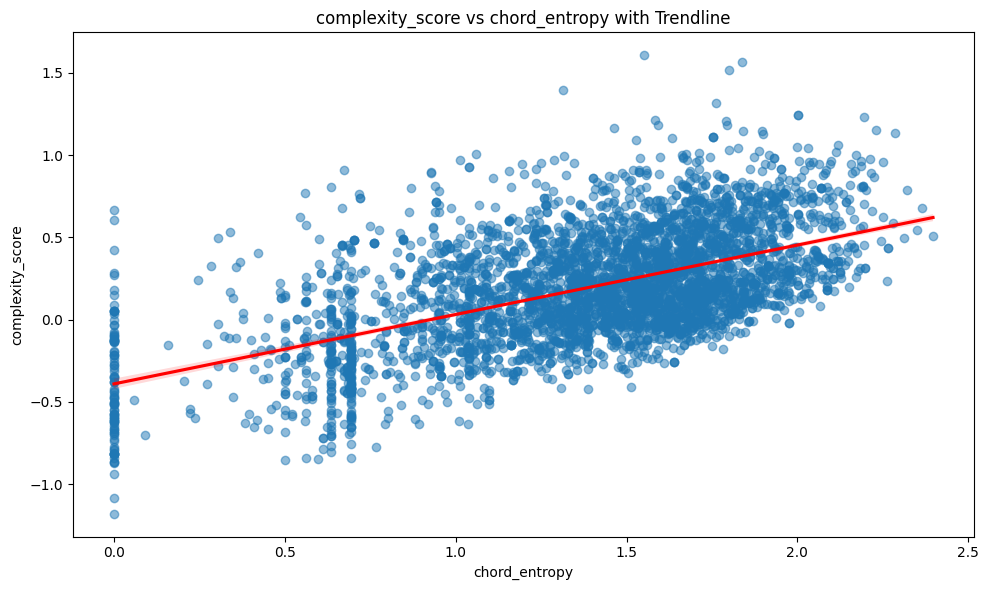

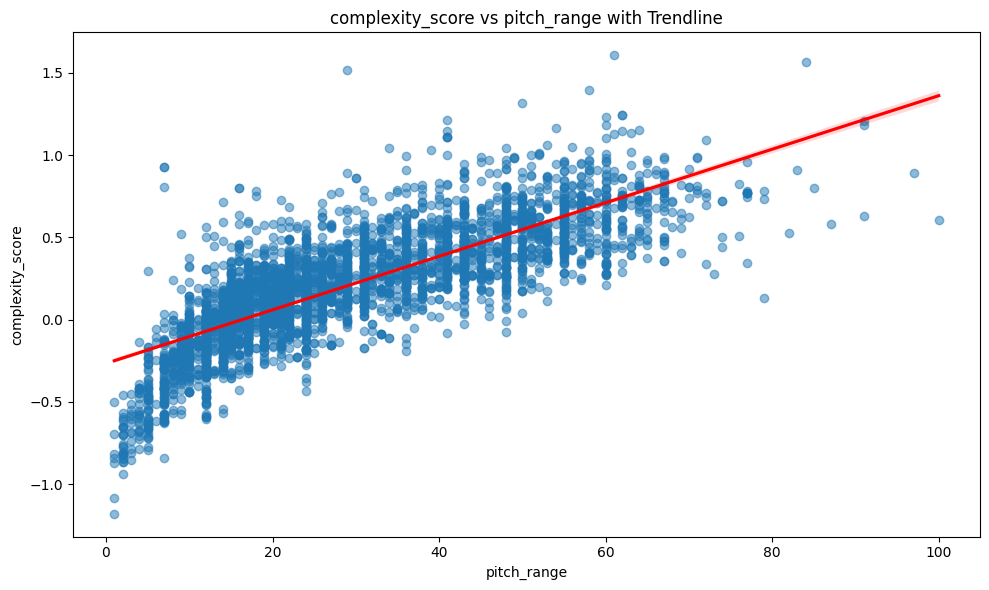

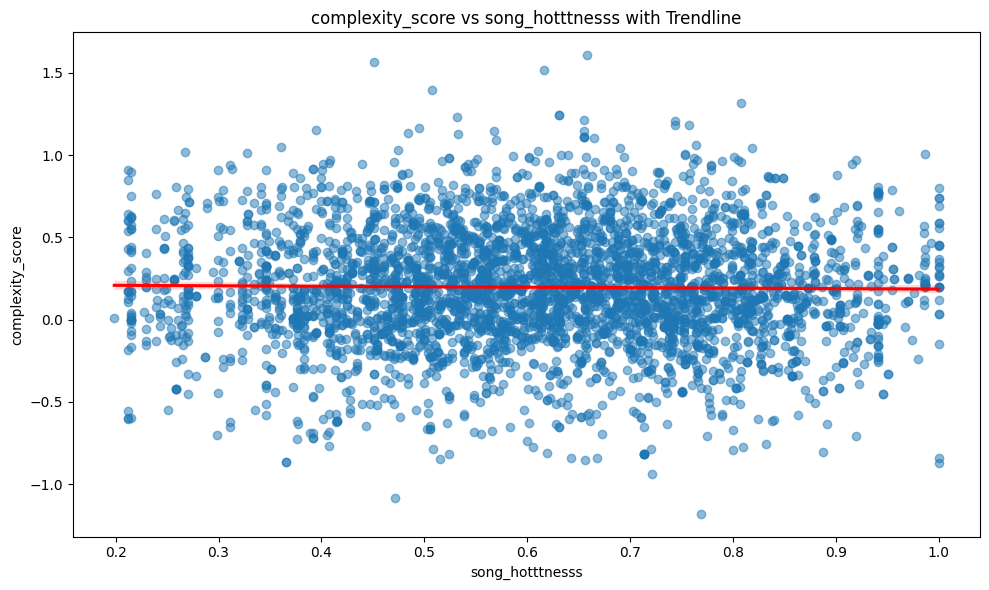

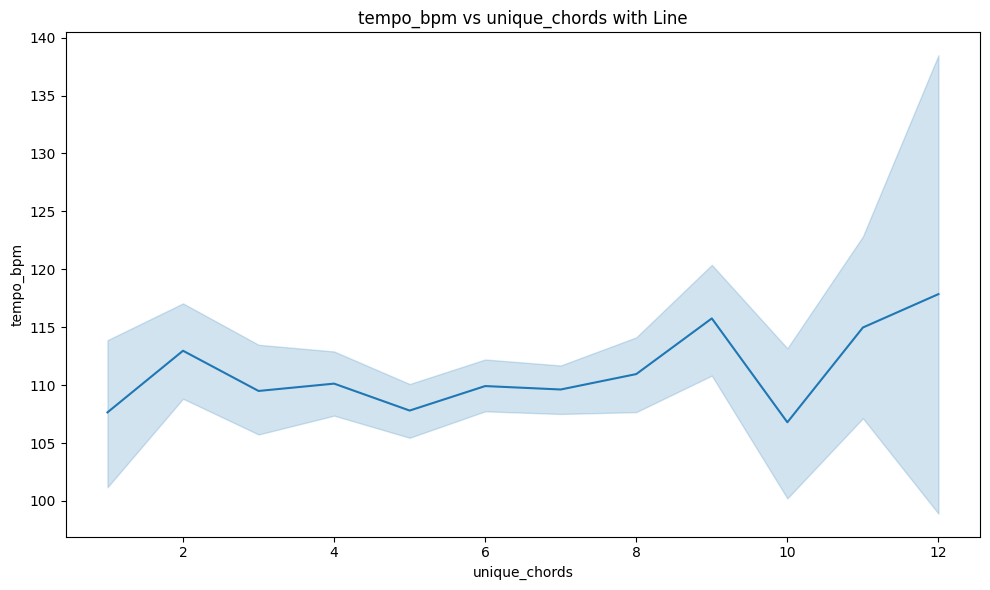

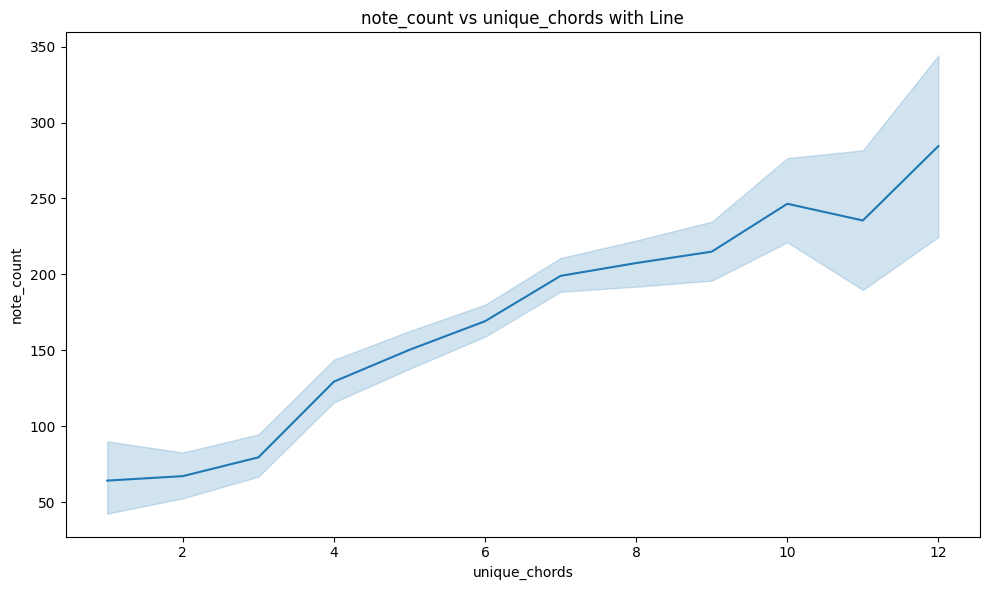

In [85]:
y = "complexity_score"
line_with_trendline(df_transformed, "unique_chords", y)
scatter_with_trendline(df_transformed, "note_count", y)
scatter_with_trendline(df_transformed, "chord_entropy", y)
scatter_with_trendline(df_transformed, "pitch_range", y)
scatter_with_trendline(df_transformed, "song_hotttnesss", y)

x = "unique_chords"
line_with_trendline(df_transformed, x, "tempo_bpm")
line_with_trendline(df_transformed, x, "note_count")

In [ ]:
# Ranked correlation of song_hotttnesss with other features
df_transformed.select_dtypes(include=np.number).corr()['song_hotttnesss'].drop('song_hotttnesss').sort_values()
    

key_confidence           -0.058549
chord_entropy            -0.054899
unique_chords            -0.054116
is_major                 -0.027873
avg_note_duration        -0.027192
melodic_interval         -0.017332
pitch_range              -0.015908
complexity_score         -0.014619
note_duration_variance   -0.009217
pitch_variance           -0.007604
note_count               -0.005369
avg_note_density          0.001963
total_measures            0.010708
tempo_bpm                 0.028564
avg_pitch                 0.052106
artist_hotttnesss         0.346763
Name: song_hotttnesss, dtype: float64

In [88]:
# Ranked correlation of complexity_score with other features
df_transformed.select_dtypes(include=np.number).corr()['complexity_score'].drop('complexity_score').sort_values()
    

key_confidence           -0.235871
avg_note_density         -0.088054
is_major                 -0.046851
note_count               -0.033793
song_hotttnesss          -0.014619
artist_hotttnesss         0.005944
avg_pitch                 0.046850
tempo_bpm                 0.061626
total_measures            0.172949
avg_note_duration         0.495505
chord_entropy             0.560325
unique_chords             0.592611
note_duration_variance    0.635207
melodic_interval          0.644632
pitch_variance            0.741739
pitch_range               0.790845
Name: complexity_score, dtype: float64

## Observations